# Parameter sensitivity figure

How do MHW frequency and cumulative intensity estimates vary across different detection
parameter choices applied to the same synthetic SST dataset?  
**Two figures** (Figs 1 & 2 below) share one set of model runs.

Detection uses `mhw3d.legacy` (Hobday 2016 convention).  
Detrended and shifting baseline helpers are prototypes for `mhw3d.best_practice`.

In [ ]:
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings('ignore')

MHW3D_SRC = (
    '/Users/neilmalan/Library/CloudStorage/'
    'GoogleDrive-neilcmalan@gmail.com/My Drive/CCRC_work/mhw3d-detection/src'
)
if MHW3D_SRC not in sys.path:
    sys.path.insert(0, MHW3D_SRC)

from mhw3d.legacy.climatology import (
    compute_climatology as legacy_clim,
    compute_threshold   as legacy_thresh,
)
from mhw3d.best_practice.climatology import detrend
from mhw3d.common.core import _detect_events, _clim_doy

%matplotlib inline

# ── Constants ──────────────────────────────────────────────────────────────
REF_START  = 1982
REF_END    = 2011
PLOT_START = 1982
PLOT_END   = 2021
GEN_START  = 1952   # burn-in so shifting baseline has 30 yr prior to 1982
SEED       = 42

## 1. Synthetic SST

`generate_sst()` builds: `base_temp + seasonal(t) + trend(t) + AR(1) noise`.  
Pass `trend_func=callable(t_years)` to swap in a nonlinear or ensemble warming signal later.

In [ ]:
def generate_sst(
    start_year=GEN_START,
    end_year=2021,
    seasonal_amplitude=1.5,   # degC
    trend_rate=0.02,           # degC yr-1  (linear)
    ar1_phi=0.9,               # daily autocorrelation
    ar1_sigma=0.5,             # innovation std (degC); stationary var = sigma^2/(1-phi^2)
    base_temp=22.0,            # degC
    trend_func=None,           # callable(t_years) -> degC, overrides linear ramp if given
    rng=None,                  # None → fresh RNG from SEED each call (reproducible)
):
    if rng is None:
        rng = np.random.default_rng(SEED)
    dates = pd.date_range(f'{start_year}-01-01', f'{end_year}-12-31', freq='D')
    n     = len(dates)
    t_yr  = np.arange(n) / 365.25
    doy   = pd.DatetimeIndex(dates).dayofyear

    seasonal = seasonal_amplitude * np.cos(2 * np.pi * (doy - 15) / 365.25)
    trend    = trend_func(t_yr) if trend_func is not None else trend_rate * t_yr

    eps   = rng.normal(0, ar1_sigma * np.sqrt(1 - ar1_phi**2), n)
    noise = np.zeros(n)
    for i in range(1, n):
        noise[i] = ar1_phi * noise[i - 1] + eps[i]

    sst = base_temp + seasonal + trend + noise
    return xr.DataArray(
        sst, coords={'time': dates}, dims=['time'],
        name='sst', attrs={'units': 'degC', 'long_name': 'Synthetic SST'},
    )


sst_full = generate_sst()
print(f'Generated {len(sst_full)} days  '
      f'({int(sst_full.time.dt.year[0])}–{int(sst_full.time.dt.year[-1])})')

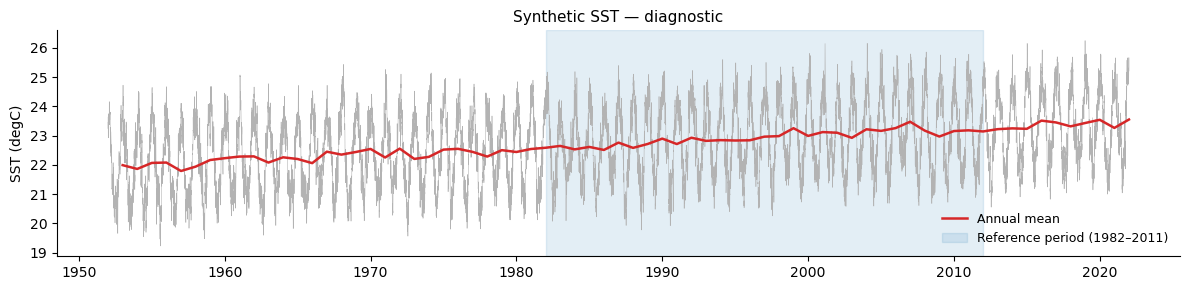

In [3]:
fig, ax = plt.subplots(figsize=(12, 3))
sst_ann = sst_full.resample(time='1YE').mean()
ax.plot(sst_full.time.values, sst_full.values, lw=0.4, color='0.7')
ax.plot(sst_ann.time.values,  sst_ann.values,  lw=1.8, color='tab:red', label='Annual mean')
ax.axvspan(
    pd.Timestamp(f'{REF_START}-01-01'), pd.Timestamp(f'{REF_END}-12-31'),
    alpha=0.12, color='tab:blue', label=f'Reference period ({REF_START}–{REF_END})',
)
ax.set_ylabel('SST (degC)')
ax.set_title('Synthetic SST — diagnostic', fontsize=11)
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 2. Climatology & threshold helpers

Three baseline types, each calling `mhw3d.legacy` functions.  
`_clim_thresh_detrended` and `_clim_thresh_shifting` are prototypes for `mhw3d.best_practice`.

In [4]:
def _clim_thresh_fixed(sst, ref_start=REF_START, ref_end=REF_END, pctile=0.90):
    """Fixed baseline: clim/thresh from the unchanging reference period."""
    clim   = legacy_clim(sst,  climatologyPeriod=(ref_start, ref_end))
    thresh = legacy_thresh(sst, pctile=pctile, climatologyPeriod=(ref_start, ref_end))
    return clim, thresh   # DataArray(dayofyear), DataArray(dayofyear)


def _clim_thresh_detrended(sst, ref_start=REF_START, ref_end=REF_END, pctile=0.90):
    """
    Detrended baseline: fit linear trend on the reference period, subtract from the
    full series, then compute clim/thresh from the detrended reference period.

    Returns (clim_doy, thresh_doy, sst_detrended).
    Prototype for mhw3d.best_practice.
    """
    sst_det = detrend(sst, period=slice(str(ref_start), str(ref_end)), deg=1)
    clim    = legacy_clim(sst_det,  climatologyPeriod=(ref_start, ref_end))
    thresh  = legacy_thresh(sst_det, pctile=pctile, climatologyPeriod=(ref_start, ref_end))
    return clim, thresh, sst_det


def _clim_thresh_shifting(sst, analysis_start=PLOT_START, analysis_end=PLOT_END,
                           window_years=30, pctile=0.90):
    """
    Shifting baseline: reference period = [y - window_years, y - 1] for each
    analysis year y.  Returns time-indexed clim and thresh DataArrays.

    Requires sst to start window_years before analysis_start (GEN_START=1952 covers this).
    Prototype for mhw3d.best_practice.
    """
    adates     = pd.date_range(f'{analysis_start}-01-01', f'{analysis_end}-12-31', freq='D')
    clim_arr   = np.full(len(adates), np.nan)
    thresh_arr = np.full(len(adates), np.nan)

    print('Shifting baseline: computing year', end=' ')
    for year in range(int(analysis_start), int(analysis_end) + 1):
        print(year, end=' ', flush=True)
        c_doy = legacy_clim(sst,  climatologyPeriod=(year - window_years, year - 1))
        t_doy = legacy_thresh(sst, pctile=pctile,
                               climatologyPeriod=(year - window_years, year - 1))

        ymask     = pd.DatetimeIndex(adates).year == year
        year_time = xr.DataArray(
            np.zeros(ymask.sum()), coords={'time': adates[ymask]}, dims=['time']
        )
        cdoy = _clim_doy(year_time.time).values   # Oliver leap-year convention

        clim_arr[ymask]   = c_doy.sel(dayofyear=cdoy).values
        thresh_arr[ymask] = t_doy.sel(dayofyear=cdoy).values
    print()

    return (
        xr.DataArray(clim_arr,   coords={'time': adates}, dims=['time']),
        xr.DataArray(thresh_arr, coords={'time': adates}, dims=['time']),
    )

## 3. Detection and annual metrics

In [5]:
def _mhw_mask(n, i_starts, i_ends):
    """Boolean array: True on every day that belongs to a detected MHW event."""
    mask = np.zeros(n, dtype=bool)
    for s, e in zip(i_starts, i_ends):
        if np.isnan(s):
            break
        mask[int(s):int(e) + 1] = True
    return mask


def run_config(sst_full, baseline_type='fixed', pctile=0.90,
               min_duration=5, max_gap=2,
               analysis_start=PLOT_START, analysis_end=PLOT_END):
    """
    Full detection pipeline for one parameter set.

    Returns
    -------
    pd.DataFrame indexed by year with columns:
        mhw_days        : int   — days per year above threshold
        cumul_intensity : float — sum of T_anom over MHW days (degC d yr-1)
    """
    analysis_years = range(analysis_start, analysis_end + 1)
    sst_plot = sst_full.sel(time=sst_full.time.dt.year.isin(analysis_years))

    # ── Clim / thresh ────────────────────────────────────────────────────────
    if baseline_type == 'fixed':
        clim, thresh = _clim_thresh_fixed(sst_full, pctile=pctile)
        sst_v = sst_plot.values

    elif baseline_type == 'detrended':
        clim, thresh, sst_det = _clim_thresh_detrended(sst_full, pctile=pctile)
        sst_plot = sst_det.sel(time=sst_det.time.dt.year.isin(analysis_years))
        sst_v = sst_plot.values

    elif baseline_type == 'shifting':
        clim, thresh = _clim_thresh_shifting(sst_full, pctile=pctile)
        sst_v = sst_plot.values

    else:
        raise ValueError(f'Unknown baseline_type: {baseline_type!r}')

    # ── Map clim/thresh onto the analysis time axis ──────────────────────────
    if 'dayofyear' in clim.dims:
        # Fixed / detrended: DOY-indexed → map with Oliver's leap-year convention
        cdoy    = _clim_doy(sst_plot.time).values
        clim_t  = clim.sel(dayofyear=cdoy).values
        thresh_t = thresh.sel(dayofyear=cdoy).values
    else:
        # Shifting: already time-indexed
        clim_t   = clim.values
        thresh_t = thresh.values

    # ── Severity (best-practice convention: np.where, not +1e-9) ─────────────
    T_anom   = sst_v - clim_t
    denom    = thresh_t - clim_t
    severity = np.where(np.abs(denom) > 1e-9, T_anom / denom, np.nan)

    # ── Event detection ───────────────────────────────────────────────────────
    n = len(sst_plot.time)
    events = _detect_events(
        np.arange(n), severity, l_return=600,
        minDuration=min_duration, maxGap=max_gap,
    )
    mask = _mhw_mask(
        n,
        events.sel(variable='index_start').values,
        events.sel(variable='index_end').values,
    )

    # ── Annual metrics ────────────────────────────────────────────────────────
    years = sst_plot.time.dt.year.values
    rows  = []
    for y in np.unique(years):
        ym = years == y
        rows.append({
            'year':            int(y),
            'mhw_days':        int(mask[ym].sum()),
            'cumul_intensity': float(T_anom[ym][mask[ym]].sum()) if mask[ym].any() else 0.0,
        })
    return pd.DataFrame(rows).set_index('year')

## 4. Parameter grid

One-at-a-time sensitivity: each panel varies one parameter while the others are held at the
**anchor** (Fixed 1982–2011, 90th pct, 5-day min, 2-day gap).  
`'k'` in each panel's colour dict marks the anchor value → rendered as black dashed bold.

In [6]:
ANCHOR = dict(baseline_type='fixed', pctile=0.90, min_duration=5, max_gap=2)

PARAM_PANELS = [
    {
        'param':   'baseline_type',
        'label':   'Baseline type',
        'values':  ['fixed', 'detrended', 'shifting'],
        'display': ['Fixed 1982–2011', 'Detrended', 'Shifting 30 yr'],
        'colors':  {'fixed': 'k', 'detrended': '#E07B39', 'shifting': '#4A90D9'},
    },
    {
        'param':   'pctile',
        'label':   'Percentile threshold',
        'values':  [0.80, 0.85, 0.90, 0.95],
        'display': ['80th', '85th', '90th', '95th'],
        'colors':  {0.80: '#A8D8EA', 0.85: '#4A9EBF', 0.90: 'k', 0.95: '#1A3A5E'},
    },
    {
        'param':   'min_duration',
        'label':   'Minimum duration (days)',
        'values':  [3, 5, 7],
        'display': ['3 days', '5 days', '7 days'],
        'colors':  {3: '#91CF60', 5: 'k', 7: '#1A7731'},
    },
    {
        'param':   'max_gap',
        'label':   'Max gap to merge events (days)',
        'values':  [1, 2, 3],
        'display': ['1 day', '2 days', '3 days'],
        'colors':  {1: '#FC8D59', 2: 'k', 3: '#B30000'},
    },
]

In [7]:
# Collect the 10 unique (baseline_type, pctile, min_duration, max_gap) combos
configs = {}
for panel in PARAM_PANELS:
    for v in panel['values']:
        cfg = {**ANCHOR, panel['param']: v}
        key = (cfg['baseline_type'], cfg['pctile'], cfg['min_duration'], cfg['max_gap'])
        configs[key] = cfg

print(f'Running {len(configs)} unique configurations...\n')
results = {}
for i, (key, cfg) in enumerate(configs.items(), 1):
    print(f'[{i}/{len(configs)}]  {cfg}')
    results[key] = run_config(sst_full, **cfg)

print('\nDone.')

Running 10 unique configurations...

[1/10]  {'baseline_type': 'fixed', 'pctile': 0.9, 'min_duration': 5, 'max_gap': 2}
[2/10]  {'baseline_type': 'detrended', 'pctile': 0.9, 'min_duration': 5, 'max_gap': 2}
[3/10]  {'baseline_type': 'shifting', 'pctile': 0.9, 'min_duration': 5, 'max_gap': 2}
Shifting baseline: computing year 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 
[4/10]  {'baseline_type': 'fixed', 'pctile': 0.8, 'min_duration': 5, 'max_gap': 2}
[5/10]  {'baseline_type': 'fixed', 'pctile': 0.85, 'min_duration': 5, 'max_gap': 2}
[6/10]  {'baseline_type': 'fixed', 'pctile': 0.95, 'min_duration': 5, 'max_gap': 2}
[7/10]  {'baseline_type': 'fixed', 'pctile': 0.9, 'min_duration': 3, 'max_gap': 2}
[8/10]  {'baseline_type': 'fixed', 'pctile': 0.9, 'min_duration': 7, 'max_gap': 2}
[9/10]  {'baseline_type': 'fixed', 'pctile': 0.9, 'min_

## 5. Figures

Shared plotting function — call with `metric='mhw_days'` or `metric='cumul_intensity'`.

In [8]:
def _anchor_key():
    return (ANCHOR['baseline_type'], ANCHOR['pctile'],
            ANCHOR['min_duration'], ANCHOR['max_gap'])


def make_sensitivity_figure(results, metric, ylabel, suptitle, save_path=None):
    """
    Four-panel one-at-a-time sensitivity figure.

    Parameters
    ----------
    metric    : 'mhw_days' or 'cumul_intensity'
    ylabel    : y-axis label string
    suptitle  : figure suptitle
    save_path : optional path to save PNG
    """
    trend_unit = 'd dec-1' if metric == 'mhw_days' else 'degC d dec-1'
    anc_key    = _anchor_key()

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()

    for ax, panel in zip(axes, PARAM_PANELS):
        for val, disp in zip(panel['values'], panel['display']):
            cfg    = {**ANCHOR, panel['param']: val}
            key    = (cfg['baseline_type'], cfg['pctile'],
                      cfg['min_duration'], cfg['max_gap'])
            color  = panel['colors'][val]
            df     = results[key]
            x, y   = df.index.values.astype(float), df[metric].values
            is_anc = (key == anc_key)

            slope, *_ = stats.linregress(x, y)
            label = f'{disp}  [{slope * 10:+.1f} {trend_unit}]'
            if is_anc:
                label += '  *'

            ax.plot(x, y,
                    color=color,
                    lw=2.5 if is_anc else 1.5,
                    ls='--' if is_anc else '-',
                    label=label,
                    zorder=5 if is_anc else 2,
                    alpha=0.9)

        ax.set_title(panel['label'], fontsize=10, fontweight='bold', pad=5)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.legend(frameon=False, fontsize=8)
        ax.grid(True, alpha=0.25, lw=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for ax in axes[2:]:
        ax.set_xlabel('Year', fontsize=9)

    fig.suptitle(suptitle, fontsize=11)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    return fig

Saved to ../plots/param_sensitivity_days.png


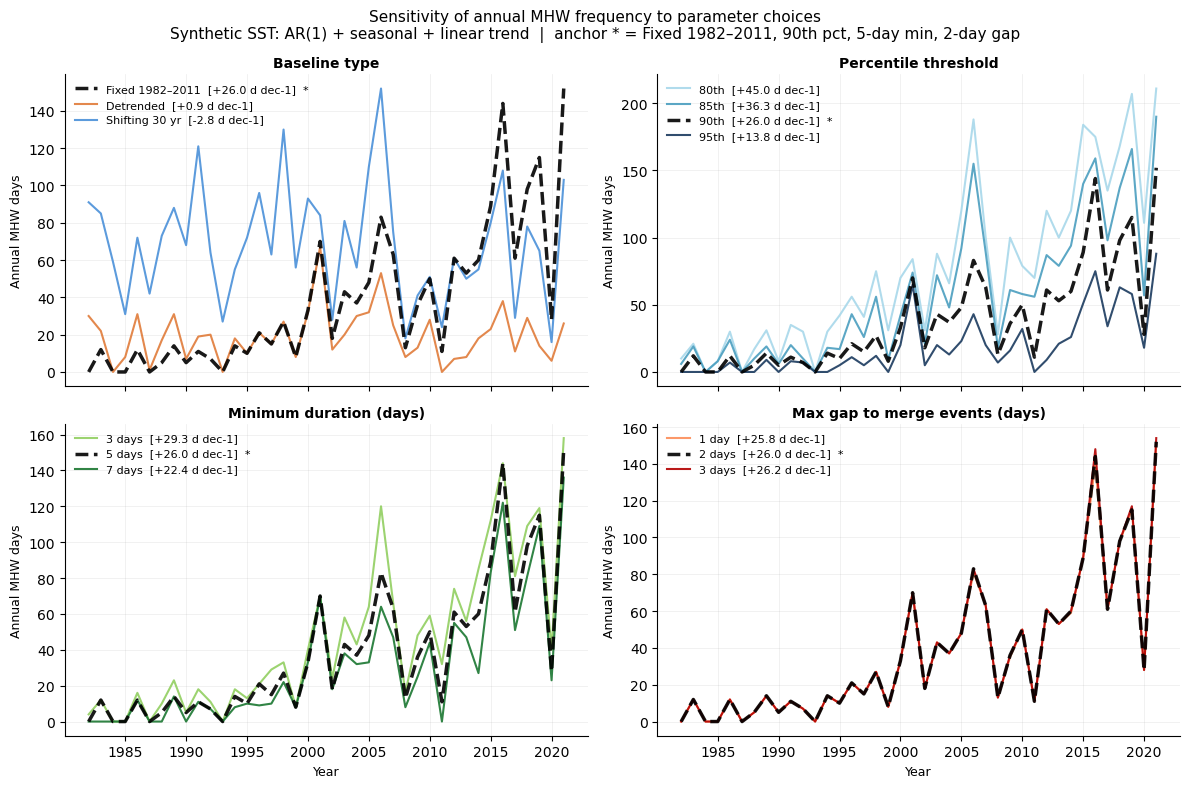

In [9]:
fig1 = make_sensitivity_figure(
    results,
    metric='mhw_days',
    ylabel='Annual MHW days',
    suptitle=(
        'Sensitivity of annual MHW frequency to parameter choices\n'
        'Synthetic SST: AR(1) + seasonal + linear trend  |  anchor * = Fixed 1982–2011, 90th pct, 5-day min, 2-day gap'
    ),
    save_path='../plots/param_sensitivity_days.png',
)
plt.show()

Saved to ../plots/param_sensitivity_intensity.png


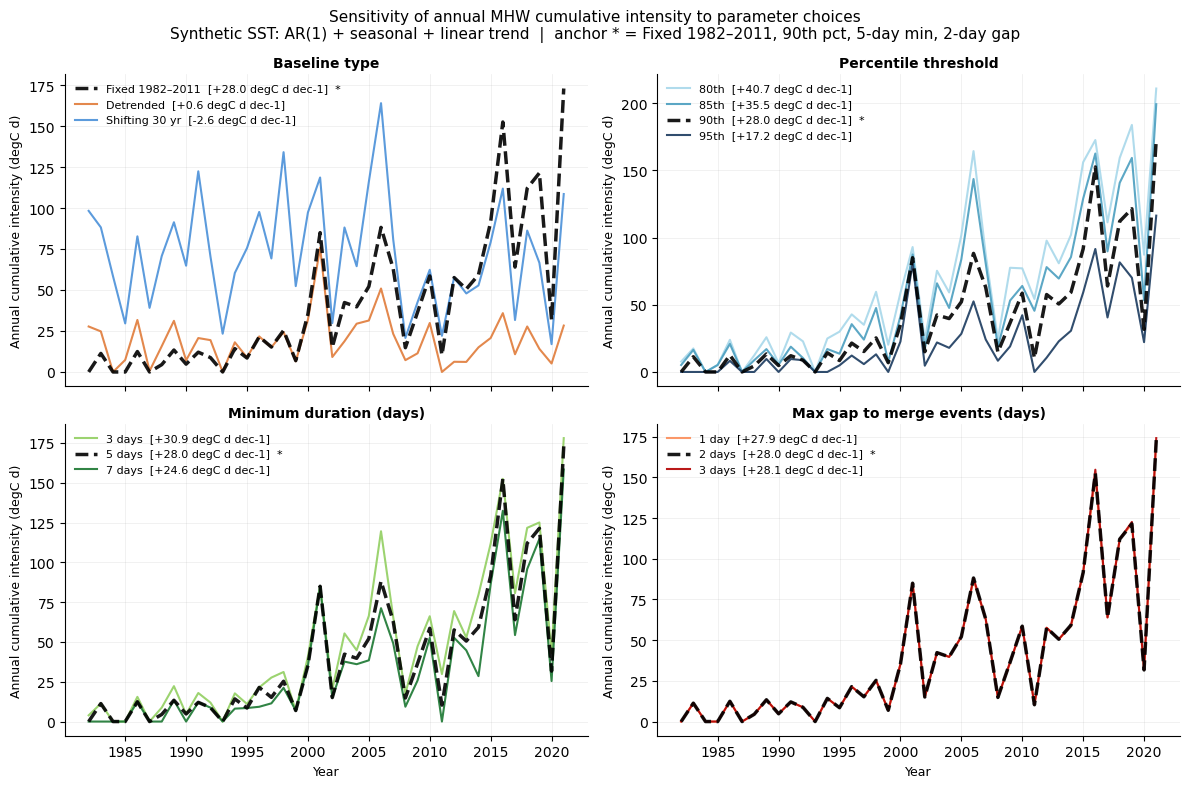

In [10]:
fig2 = make_sensitivity_figure(
    results,
    metric='cumul_intensity',
    ylabel='Annual cumulative intensity (degC d)',
    suptitle=(
        'Sensitivity of annual MHW cumulative intensity to parameter choices\n'
        'Synthetic SST: AR(1) + seasonal + linear trend  |  anchor * = Fixed 1982–2011, 90th pct, 5-day min, 2-day gap'
    ),
    save_path='../plots/param_sensitivity_intensity.png',
)
plt.show()